## Fórmula

O Random Forest não tem uma fórmula única.

Ele combina várias árvores de decisão independentes e usa votação (classificação) ou média (regressão) para gerar o resultado final.

## Características

É um modelo baseado em múltiplas árvores, criando um conjunto (ensemble).

Cada árvore recebe uma amostra diferente dos dados (bootstrap) e usa apenas parte das variáveis a cada divisão.

Reduz drasticamente overfitting comum em Decision Trees.

Funciona bem mesmo sem ajustes finos.

Pode ser usado tanto para classificação quanto regressão.

É robusto a ruídos, valores extremos e variáveis irrelevantes.

## Hiperparâmetro

n_estimators – quantidade de árvores na floresta.

max_depth – profundidade máxima das árvores (controla overfitting).

max_features – quantas variáveis cada árvore considera por split.

min_samples_split / min_samples_leaf – tamanho mínimo para dividir folhas.

## Funcionamento

1. Cria várias árvores de decisão usando amostras sorteadas dos dados.

2. Cada árvore gera sua própria predição.

3. O modelo combina todas as árvores:

    Classificação → votação da maioria

    Regressão → média das previsões


## Random Forest para Classificação

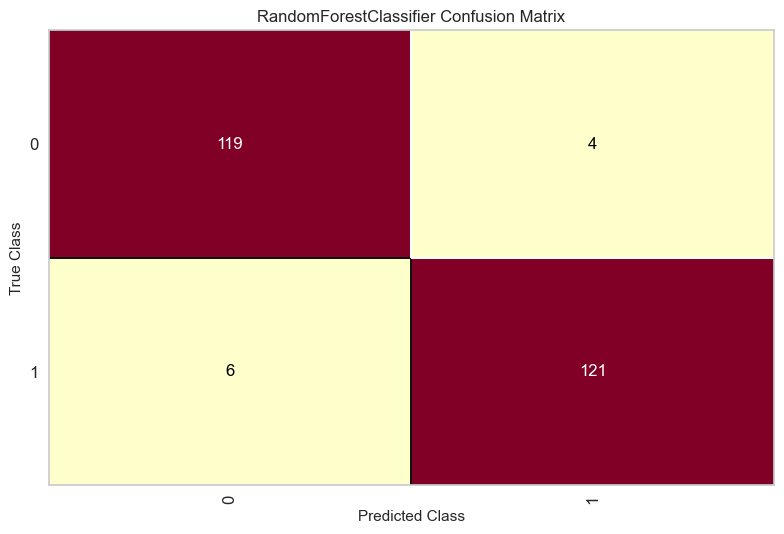

Accuracy: 0.96


In [1]:
# ===============================
# 1. Criar base de dados sintética
# ===============================
from sklearn.datasets import make_classification  # import usado apenas aqui

X, y = make_classification(
    n_samples=1000,      # quantidade de amostras
    n_features=4,        # número de colunas (features)
    n_informative=3,     # features realmente úteis
    n_redundant=0,       # sem colunas repetidas
    n_classes=2,         # classificação binária
    random_state=42
)


# ===============================
# 2. Separar treino e teste
# ===============================
from sklearn.model_selection import train_test_split  # import usado apenas aqui

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)


# ===============================
# 3. Criar e treinar o modelo
# ===============================
from sklearn.ensemble import RandomForestClassifier  # import acima do uso

modelo = RandomForestClassifier(
    n_estimators=100,    # número de árvores
    max_depth=None,      # sem limite de profundidade
    random_state=42
)

modelo.fit(X_train, y_train)


# ===============================
# 4. Fazer previsões
# ===============================
y_pred = modelo.predict(X_test)


# ===============================
# 5. Métrica: Accuracy
# ===============================
from sklearn.metrics import accuracy_score  # import acima do uso

accuracy = accuracy_score(y_test, y_pred)


# ===============================
# 6. Matriz de Confusão (Yellowbrick)
# ===============================
from yellowbrick.classifier import ConfusionMatrix  # import acima do uso

cm = ConfusionMatrix(modelo)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)
cm.show()


# ===============================
# 7. Exibir resultados
# ===============================
print("Accuracy:", accuracy)


## Random Forest para Regressão

In [2]:
# ===============================
# 1. Criar base de dados sintética
# ===============================
from sklearn.datasets import make_regression  # import usado apenas aqui

X, y = make_regression(
    n_samples=600,      # quantidade de amostras
    n_features=5,       # número de colunas
    noise=20,           # ruído para simular imperfeição real
    random_state=42
)


# ===============================
# 2. Separar treino e teste
# ===============================
from sklearn.model_selection import train_test_split  # import acima do uso

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)


# ===============================
# 3. Criar e treinar o modelo
# ===============================
from sklearn.ensemble import RandomForestRegressor  # import acima do uso

modelo = RandomForestRegressor(
    n_estimators=200,    # quantidade de árvores
    max_depth=None,      # sem limite de profundidade
    random_state=42
)

modelo.fit(X_train, y_train)


# ===============================
# 4. Fazer previsões
# ===============================
y_pred = modelo.predict(X_test)


# ===============================
# 5. Métricas: MAE e MSE
# ===============================
from sklearn.metrics import mean_absolute_error  # import acima do uso
from sklearn.metrics import mean_squared_error  # import acima do uso

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)


# ===============================
# 6. Score (R²) Treino e Teste
# ===============================
from sklearn.metrics import r2_score  # import acima do uso

score_treino = r2_score(y_train, modelo.predict(X_train))
score_teste  = r2_score(y_test,  y_pred)


# ===============================
# 7. Exibir resultados
# ===============================
print("Score Treino (R²):", score_treino)
print("Score Teste  (R²):", score_teste)
print("MAE:", mae)
print("MSE:", mse)


Score Treino (R²): 0.9853838204145992
Score Teste  (R²): 0.8471180454670135
MAE: 42.262705799811556
MSE: 3695.509960450982
